In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df=pd.read_csv('tram_charcoal_zscores.csv')
df

,SampleId,age,sumCharArea,depth,Density,Mass,sed_rate,CHAR.tram,CHAR.z_scores
0,TRAM-3U-19-20,863,18403.1051,390,0.773143,1.5025,0.051282,485.625812,-0.600658
1,TRAM-3U-20-21,902,19629.9787,392,0.714385,1.6349,0.051282,439.871796,-0.615820
2,TRAM-3U-21-22,939,22083.7261,394,0.654214,1.6743,0.054054,466.430960,-0.607018
3,TRAM-3U-22-23,959,28218.0945,395,0.655773,1.5234,0.050000,607.347275,-0.560321
4,TRAM-3U-23-24,999,0.0000,397,0.466250,1.5846,0.050000,0.000000,-0.761586
...,...,...,...,...,...,...,...,...,...
197,TRAM-4U-115-116,11280,24537.4735,717,0.411030,1.5248,0.026316,174.063122,-0.703905
198,TRAM-4U-116-117,11316,106738.0097,718,0.441613,1.5483,0.027778,845.675126,-0.481343
199,TRAM-4U-117-118,11378,182804.1774,720,0.253447,1.5428,0.032258,968.726520,-0.440566
200,TRAM-4U-118-119,11401,223291.0088,721,0.361723,1.5478,0.043478,2268.845988,-0.009726


In [3]:
df_basa_full=pd.read_csv('tram20_PAR.csv')

non_aquatic_species = 'Abies,Pinus,Juniperus,Taxus,Betula,Corylus,Alnus,Carpinus,Salix,Ulmus,Populus,Acer,Fraxinus,Fagus,Tilia,Juglans,Castanea,Quercus caducifolio,Quercus perennifolio,Pistacia,Rhamnus,Phillyrea,Buxus,Sambucus,Viburnum,Sanguisorba,Tamarix,Thymelaeaceae,Ephedra distachya,Ephedra fragilis,Ericaceae,Hereda helix,Ilex aquifolium,Viscum album,Lonicera,Vitis,Oleaceae,Myrtus,Olea,Poaceae,Lygeum spartum,Artemisia,Cichorioideae,Asteroideae,Cardueae,Rubiaceae,Centaurea,Chenopodiaceae,Caryophyllaceae,Plantago,Brassicaceae,Saxifragaceae,Fabaceae,Genista,Lotus type,Trifolium type,Rosaceae,Ribes,Boraginaceae,Sedum,Helianthemum,Lamiaceae,Urticaceae,Rumex,Berberidaceae,Euphorbiaceae,Primulaceae,Scrophulariaceae,Papaver,Campanulaceae,Convolvulaceae,Liliaceae,Iridaceae,Crassulaceae,Ranunculaceae,Cistaceae,Galium,Apiaceae,Valerianaceae,Cerealia type,Polygonaceae,Ranunculus'

species_mapping = {
        "Dec_Querc": "Quercus caducifolio",
        "Ever_Querc": "Quercus perennifolio",
        "Ephedra dist": "Ephedra distachya",
        "Ephedra frag": "Ephedra fragilis",
        "Lygeum": "Lygeum spartum",
        "Cicho": "Cichorioideae",
        "Astroi": "Asteroideae",
        "Carduaceae": "Cardueae",
        "Rubiac": "Rubiaceae",
        "Chenopo": "Chenopodiaceae",
        "Caryphy": "Caryophyllaceae",
        "Brassicac": "Brassicaceae",
        "Saxifrag": "Saxifragaceae",
        "Boraginac": "Boraginaceae",
        "Helianthem": "Helianthemum",
        "Euphorbiac": "Euphorbiaceae",
        "Primulac": "Primulaceae",
        "Scrophulari": "Scrophulariaceae",
        "Campanulac": "Campanulaceae",
        "Valerian": "Valerianaceae",
        "Cerealia": "Cerealia type",
        "Polygon": "Polygonaceae"
    }

In [4]:
df_basa_full

,depth,age,Abies,Pinus,Juniperus,Taxus,Alnus,Acer,Betula,Castanea,...,Juncaceae,Ranunculaceae t Ranunculus,Sparganium,Typha,Callitriche,Myriophyllum,Nymphaea,Potamogeton,Utricularia,Undetermined
0,390,863,199.439215,437.899147,69.370162,0.0,0.000000,0.000000,30.349446,0.000000,...,34.685081,17.342540,0.000000,0.000000,13.006905,13.006905,17.342540,0.000000,0.0,177.761040
1,395,959,266.830454,695.163550,84.262248,0.0,0.000000,0.000000,21.065562,0.000000,...,0.000000,7.021854,0.000000,0.000000,0.000000,0.000000,56.174832,0.000000,0.0,0.000000
2,398,1020,282.078022,789.818462,43.878803,0.0,25.073602,0.000000,31.342002,0.000000,...,18.805201,18.805201,0.000000,0.000000,0.000000,0.000000,50.147204,0.000000,0.0,87.757607
3,403,1077,255.733515,558.825089,142.074175,0.0,9.471612,0.000000,47.358058,9.471612,...,37.886447,18.943223,37.886447,0.000000,0.000000,0.000000,208.375457,0.000000,0.0,161.017398
4,406,1106,463.370907,549.762093,125.659907,0.0,70.683698,15.707488,31.414977,0.000000,...,62.829953,0.000000,0.000000,0.000000,0.000000,0.000000,70.683698,0.000000,0.0,70.683698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,705,10621,0.000000,490.165091,30.635318,0.0,0.000000,0.000000,1286.683363,0.000000,...,0.000000,12.254127,0.000000,0.000000,12.254127,24.508255,0.000000,6.127064,0.0,36.762382
77,708,10843,0.000000,446.514810,4.212404,0.0,0.000000,0.000000,631.860580,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,25.274423
78,713,11106,5.612543,1150.571285,11.225086,0.0,0.000000,0.000000,611.767171,0.000000,...,0.000000,11.225086,0.000000,0.000000,0.000000,5.612543,0.000000,0.000000,0.0,101.025771
79,717,11280,0.000000,898.457665,62.269343,0.0,0.000000,0.000000,1183.117519,0.000000,...,17.791241,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,71.164964


In [5]:
df_basa_full = df_basa_full.rename(columns=species_mapping)

non_aquatic_species = [s.strip() for s in non_aquatic_species.split(',')]
df_bas = df_basa_full[
    list(df_basa_full.columns[:8]) +
    [c for c in df_basa_full.columns[8:] if c in non_aquatic_species]
]
#cambiar nombre de la columna 'age' a 'cal BP'
df_bas = df_bas.rename(columns={'age': 'cal BP'})

df_bas.head()

,depth,cal BP,Abies,Pinus,Juniperus,Taxus,Alnus,Acer,Betula,Castanea,...,Caryophyllaceae,Chenopodiaceae,Crassulaceae,Iridaceae,Liliaceae,Plantago,Ranunculaceae,Rubiaceae,Rumex,Urticaceae
0,390,863,199.439215,437.899147,69.370162,0.0,0.000000,0.000000,30.349446,0.000000,...,13.006905,8.671270,0.0,0.0,8.67127,130.069054,0.0,0.0,17.342540,0.0
1,395,959,266.830454,695.163550,84.262248,0.0,0.000000,0.000000,21.065562,0.000000,...,7.021854,49.152978,0.0,0.0,0.00000,133.415227,0.0,0.0,28.087416,0.0
2,398,1020,282.078022,789.818462,43.878803,0.0,25.073602,0.000000,31.342002,0.000000,...,12.536801,37.610403,0.0,0.0,0.00000,112.831209,0.0,0.0,18.805201,0.0
3,403,1077,255.733515,558.825089,142.074175,0.0,9.471612,0.000000,47.358058,9.471612,...,18.943223,56.829670,0.0,0.0,0.00000,265.205127,0.0,0.0,75.772893,0.0
4,406,1106,463.370907,549.762093,125.659907,0.0,70.683698,15.707488,31.414977,0.000000,...,0.000000,15.707488,0.0,0.0,0.00000,149.221139,0.0,0.0,23.561233,0.0


Text(0.5, 1.0, 'Relación entre Cal BP y Suma de Abundancias (No Acuáticas)')

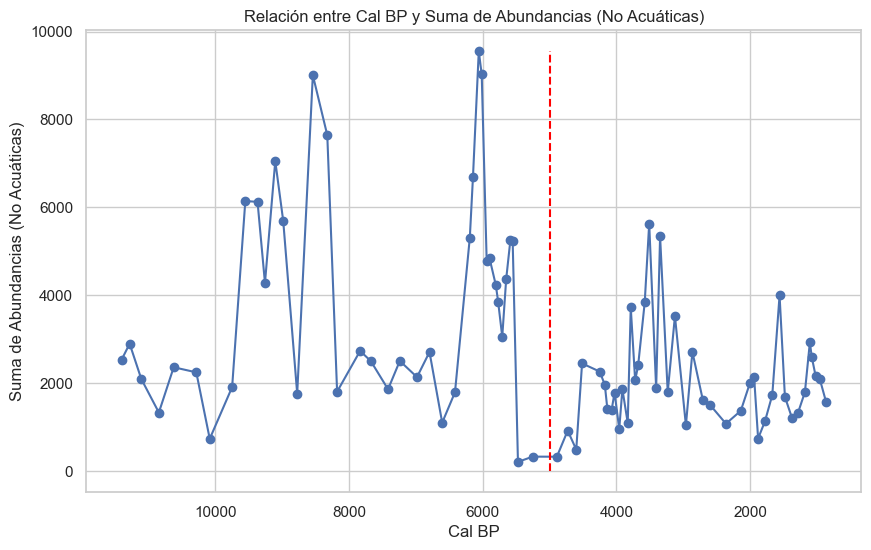

In [46]:
#plotear frente a cal BP la suma de las abundancias de las especies no acuáticas
#cal BP alto significa más viejo, el eje x tiene que ir de viejo a nuevo, es decir, de cal BP alto a cal BP bajo
df_plot= df_bas.copy()
df_plot['suma_no_acuaticas'] = df_plot.iloc[:, 2:].sum(axis=1)
#ordenar el eje x de cal BP de mayor a menor
df_plot = df_plot.sort_values('cal BP', ascending=False)
plt.figure(figsize=(10, 6))
plt.plot(df_plot['cal BP'], df_plot['suma_no_acuaticas'], marker='o')
plt.vlines(x=5000, ymin=0, ymax=df_plot['suma_no_acuaticas'].max(), color='red', linestyle='--', label='5000 cal BP')
plt.xlabel('Cal BP')
#invertir el eje x para que vaya de mayor a menor
plt.gca().invert_xaxis()
plt.ylabel('Suma de Abundancias (No Acuáticas)')
plt.title('Relación entre Cal BP y Suma de Abundancias (No Acuáticas)')

#plt.xlim(4000,6000)

In [7]:
import pandas as pd 
import numpy as np 
import pickle 
from pygam import LinearGAM, s 
from sklearn.preprocessing import StandardScaler 
from statsmodels.tsa.api import VAR 
import warnings 
warnings.filterwarnings('ignore') 
# ===================================================== 
# # CONFIGURACIÓN 
# # ===================================================== 
CSV_TEMPERATURA = "delta.csv" 
N_SPLINES_BASE = 81 
LAMBDA_GAM = 0.01 
MIN_PRESENCIA = 0 
UMBRAL_P_VALUE = 0.05 

WINDOWS = { "1": (12000, 5000), 
           "2": (5000,0) }

# =====================================================
# FUNCIÓN GENERAL POR VENTANA
# =====================================================

def procesar_ventana(nombre_ventana, rango, df_bas, df_temp):

    t_max, t_min = rango
    print(f"\n==============================")
    print(f"VENTANA {nombre_ventana}: {t_max} - {t_min}")
    print(f"==============================")

    # ---------------------------------
    # Filtrar datos originales
    # ---------------------------------
    df_window = df_bas[
        (df_bas["cal BP"] <= t_max) &
        (df_bas["cal BP"] >= t_min)
    ].copy()

    # ordenar por tiempo
    df_window = df_window.sort_values("cal BP")

    tiempos_objetivo = df_window["cal BP"].values

    # ---------------------------------
    # RECONSTRUCCIÓN ESPECIES
    # ---------------------------------
    df_reconstruido = pd.DataFrame({
        "cal BP": tiempos_objetivo
    })

    especies_cols = df_bas.columns[
        df_bas.columns.get_loc('Abies'):
    ]

    especies_validas = []

    print("\n=== GAM ESPECIES ===")

    for sp in especies_cols:
        try:
            gam = LinearGAM(
                s(0, n_splines=N_SPLINES_BASE, lam=LAMBDA_GAM)
            )
            gam.fit(df_bas[['cal BP']], df_bas[sp].values)
            #gam.fit(df_window[['cal BP']], df_window[sp].values)

            pred = gam.predict(tiempos_objetivo.reshape(-1, 1))

            df_reconstruido[sp] = pred
            especies_validas.append(sp)

        except:
            continue

    print("Especies válidas:", len(especies_validas))

    # ---------------------------------
    # TEMPERATURA
    # ---------------------------------
    df_temp['cal BP'] = df_temp['age_kyr_BP'] * 1000
    mask = df_temp['d13C'].notna()

    tiempo_temp = df_temp.loc[mask, 'cal BP'].values.reshape(-1, 1)
    valores_temp = df_temp.loc[mask, 'd13C'].values

    gam_temp = LinearGAM(
        s(0, n_splines=N_SPLINES_BASE, lam=LAMBDA_GAM)
    )
    gam_temp.fit(tiempo_temp, valores_temp)

    df_reconstruido["Temperatura"] = gam_temp.predict(
        tiempos_objetivo.reshape(-1, 1)
    )

    # ---------------------------------
    # GUARDAR
    # ---------------------------------
    nombre_archivo = f"trama_gam_ventana_{nombre_ventana}.pkl"
    df_reconstruido.to_pickle(nombre_archivo)

    print(f"\nArchivo guardado: {nombre_archivo}")

    return df_reconstruido


# cargar temperatura
df_temp = pd.read_csv(CSV_TEMPERATURA)
df_temp.columns = ['age_kyr_BP', 'depth', 'd13C']

resultados = {}

for nombre, rango in WINDOWS.items():
    resultados[nombre] = procesar_ventana(
        nombre,
        rango,
        df_bas,
        df_temp
    )





VENTANA 1: 12000 - 5000

=== GAM ESPECIES ===
did not converge
Especies válidas: 40

Archivo guardado: trama_gam_ventana_1.pkl

VENTANA 2: 5000 - 0

=== GAM ESPECIES ===
did not converge
Especies válidas: 40

Archivo guardado: trama_gam_ventana_2.pkl


In [ ]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

WINDOW_NAME = "2"   # 👈 CAMBIA AQUÍ

N_BOOTSTRAP = 4000
MIN_PRESENCIA = 1
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.5

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Temperatura"] = df["Temperatura"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        data = pd.DataFrame({
            sp1: df[sp1].values,
            sp2: df[sp2].values,
            "Temp": df["Temperatura"].values
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return np.nan

# =====================================================
# CARGAR DATOS DE LA VENTANA
# =====================================================

nombre_archivo = f"trama_gam_ventana_{WINDOW_NAME}.pkl"

with open(nombre_archivo, "rb") as f:
    df_w = pickle.load(f)

df_w = df_w.sort_values("cal BP", ascending=False).reset_index(drop=True)

print(f"\nArchivo cargado: {nombre_archivo}")
print(f"Tamaño ventana: {len(df_w)}")

# detectar especies
especies_cols = [c for c in df_w.columns if c not in ["cal BP", "Temperatura"]]

# filtrar especies válidas
especies_ventana = [
    sp for sp in especies_cols
    if es_serie_valida(df_w[sp])
]

n_w = len(especies_ventana)
print(f"Especies válidas: {n_w}")

if n_w < 2:
    raise ValueError("Muy pocas especies para análisis")

np.random.seed(42)

# =====================================================
# BOOTSTRAP
# =====================================================

print("\nGenerando bootstrap...")

boot_windows = [
    generar_bootstrap_df(df_w, especies_ventana)
    for _ in range(N_BOOTSTRAP)
]

# =====================================================
# MATRICES
# =====================================================

matriz_coef = np.full((n_w, n_w), np.nan)
matriz_sig = np.zeros((n_w, n_w))
matriz_pval = np.full((n_w, n_w), np.nan)
matriz_mean = np.full((n_w, n_w), np.nan)
matriz_std = np.full((n_w, n_w), np.nan)

valid_original = 0
n_sig = 0
n_low = 0
n_high = 0

# =====================================================
# LOOP PARES
# =====================================================

for i, sp1 in enumerate(especies_ventana):
    for j, sp2 in enumerate(especies_ventana):

        if i == j:
            continue

        coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

        if np.isnan(coef_original):
            continue

        valid_original += 1
        matriz_coef[i, j] = coef_original

        coefs_boot = []

        for df_b in boot_windows:
            coef_boot = coef_sp1_a_sp2_condicional(df_b, sp1, sp2)
            if not np.isnan(coef_boot):
                coefs_boot.append(coef_boot)

        coefs_boot = np.array(coefs_boot)

        if len(coefs_boot) == 0:
            continue

        matriz_mean[i, j] = np.mean(coefs_boot)
        matriz_std[i, j] = np.std(coefs_boot)

        count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
        p_value = count / len(coefs_boot)

        matriz_pval[i, j] = p_value

        if p_value < ALPHA:
            n_sig += 1
            if coef_original > 0:
                matriz_sig[i, j] = 1
                n_high += 1
            elif coef_original < 0:
                matriz_sig[i, j] = -1
                n_low += 1

# =====================================================
# RESULTADOS
# =====================================================

print("\n=== RESULTADOS ===")

if valid_original > 0:
    print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

if n_sig > 0:
    print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")

print(f"Cola alta: {n_high}")

# =====================================================
# GUARDAR
# =====================================================

resultado = {
    "especies": especies_ventana,
    "matriz_coeficientes": matriz_coef,
    "matriz_significancia": matriz_sig,
    "matriz_pvalores": matriz_pval,
    "matriz_medias": matriz_mean,
    "matriz_desviaciones": matriz_std
}

nombre_salida = f"resultado_red_ventana_{WINDOW_NAME}.pkl"

with open(nombre_salida, "wb") as f:
    pickle.dump(resultado, f)

print(f"\nArchivo guardado: {nombre_salida}")
print("\nProceso terminado correctamente.")


Archivo cargado: trama_gam_ventana_2.pkl
Tamaño ventana: 42
Especies válidas: 37

Generando bootstrap...

=== RESULTADOS ===
Significativos: 40 (3.00%)
Cola baja: 9 (22.50%)
Cola alta: 31

Archivo guardado: resultado_red_ventana_2.pkl

Proceso terminado correctamente.


In [ ]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

WINDOW_NAME = "1"   # 👈 CAMBIA AQUÍ

N_BOOTSTRAP = 4000
MIN_PRESENCIA = 1
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.5

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Temperatura"] = df["Temperatura"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        data = pd.DataFrame({
            sp1: df[sp1].values,
            sp2: df[sp2].values,
            "Temp": df["Temperatura"].values
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return np.nan

# =====================================================
# CARGAR DATOS DE LA VENTANA
# =====================================================

nombre_archivo = f"trama_gam_ventana_{WINDOW_NAME}.pkl"

with open(nombre_archivo, "rb") as f:
    df_w = pickle.load(f)

df_w = df_w.sort_values("cal BP", ascending=False).reset_index(drop=True)

print(f"\nArchivo cargado: {nombre_archivo}")
print(f"Tamaño ventana: {len(df_w)}")

# detectar especies
especies_cols = [c for c in df_w.columns if c not in ["cal BP", "Temperatura"]]

# filtrar especies válidas
especies_ventana = [
    sp for sp in especies_cols
    if es_serie_valida(df_w[sp])
]

n_w = len(especies_ventana)
print(f"Especies válidas: {n_w}")

if n_w < 2:
    raise ValueError("Muy pocas especies para análisis")

np.random.seed(42)

# =====================================================
# BOOTSTRAP
# =====================================================

print("\nGenerando bootstrap...")

boot_windows = [
    generar_bootstrap_df(df_w, especies_ventana)
    for _ in range(N_BOOTSTRAP)
]

# =====================================================
# MATRICES
# =====================================================

matriz_coef = np.full((n_w, n_w), np.nan)
matriz_sig = np.zeros((n_w, n_w))
matriz_pval = np.full((n_w, n_w), np.nan)
matriz_mean = np.full((n_w, n_w), np.nan)
matriz_std = np.full((n_w, n_w), np.nan)

valid_original = 0
n_sig = 0
n_low = 0
n_high = 0

# =====================================================
# LOOP PARES
# =====================================================

for i, sp1 in enumerate(especies_ventana):
    for j, sp2 in enumerate(especies_ventana):

        if i == j:
            continue

        coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

        if np.isnan(coef_original):
            continue

        valid_original += 1
        matriz_coef[i, j] = coef_original

        coefs_boot = []

        for df_b in boot_windows:
            coef_boot = coef_sp1_a_sp2_condicional(df_b, sp1, sp2)
            if not np.isnan(coef_boot):
                coefs_boot.append(coef_boot)

        coefs_boot = np.array(coefs_boot)

        if len(coefs_boot) == 0:
            continue

        matriz_mean[i, j] = np.mean(coefs_boot)
        matriz_std[i, j] = np.std(coefs_boot)

        count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
        p_value = count / len(coefs_boot)

        matriz_pval[i, j] = p_value

        if p_value < ALPHA:
            n_sig += 1
            if coef_original > 0:
                matriz_sig[i, j] = 1
                n_high += 1
            elif coef_original < 0:
                matriz_sig[i, j] = -1
                n_low += 1

# =====================================================
# RESULTADOS
# =====================================================

print("\n=== RESULTADOS ===")

if valid_original > 0:
    print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

if n_sig > 0:
    print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")

print(f"Cola alta: {n_high}")

# =====================================================
# GUARDAR
# =====================================================

resultado = {
    "especies": especies_ventana,
    "matriz_coeficientes": matriz_coef,
    "matriz_significancia": matriz_sig,
    "matriz_pvalores": matriz_pval,
    "matriz_medias": matriz_mean,
    "matriz_desviaciones": matriz_std
}

nombre_salida = f"resultado_red_ventana_{WINDOW_NAME}.pkl"

with open(nombre_salida, "wb") as f:
    pickle.dump(resultado, f)

print(f"\nArchivo guardado: {nombre_salida}")
print("\nProceso terminado correctamente.")


Archivo cargado: trama_gam_ventana_1.pkl
Tamaño ventana: 39
Especies válidas: 37

Generando bootstrap...

=== RESULTADOS ===
Significativos: 64 (4.80%)
Cola baja: 10 (15.62%)
Cola alta: 54

Archivo guardado: resultado_red_ventana_1.pkl

Proceso terminado correctamente.


# nose

In [26]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.9

WINDOWS = {
    "1": (12000, 5000)
    #"2": (5000,0)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    #df_boot["Temperatura"] = df["Temperatura"].values
    #df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, cal_min, cal_max):
    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))
    return df[mask].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        #temp = df["Temperatura"]
        #mult = df["Multiplier"]

        # if (np.std(x) < MIN_VAR or
        #     np.std(y) < MIN_VAR or
        #     np.std(temp) < MIN_VAR or
        #     np.std(mult) < MIN_VAR):
        #     return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y
            #"Temp": temp,
            #"Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("trama_gam.pkl", "rb") as f:
    df_original = pickle.load(f)

df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

#especies_cols = [c for c in df_original.columns if c not in ["cal BP", "Temperatura", "Multiplier"]]
especies_cols = [c for c in df_original.columns if c not in ["cal BP"]]

print("len", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]
    

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_value = count / len(coefs_boot)

            matriz_pval[i, j] = p_value

            if p_value < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
    print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    # with open(f"trama_{window_name}.pkl", "wb") as f:
    #     pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

len 40

VENTANA: 1
Tamaño ventana: 49 observaciones
Especies válidas en ventana: 34

Generando bootstrap...
Significativos: 62 (5.53%)
Cola baja: 7 (11.29%)
Cola alta: 55

Proceso terminado correctamente.


In [ ]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 1
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.5

WINDOWS = {
    #"1": (12000, 5000),
    "2": (5000,0)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Temperatura"] = df["Temperatura"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, cal_min, cal_max):
    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))
    return df[mask].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        temp = df["Temperatura"]

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Temp": temp
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("trama_gam.pkl", "rb") as f:
    df_original = pickle.load(f)

df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [c for c in df_original.columns if c not in ["cal BP", "Temperatura"]]

print("len", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]
    

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)
    matriz_mean = np.full((n_w, n_w), np.nan)
    matriz_std = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original
            

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            matriz_mean[i, j] = np.mean(coefs_boot)
            matriz_std[i, j] = np.std(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_value = count / len(coefs_boot)

            matriz_pval[i, j] = p_value

            if p_value < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
    print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval,
        "matriz_medias": matriz_mean,
        "matriz_desviaciones": matriz_std
    }

    # with open(f"trama_{window_name}.pkl", "wb") as f:
    #     pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

len 40

VENTANA: 2
Tamaño ventana: 32 observaciones
Especies válidas en ventana: 34

Generando bootstrap...
Significativos: 33 (2.94%)
Cola baja: 5 (15.15%)
Cola alta: 28

Proceso terminado correctamente.


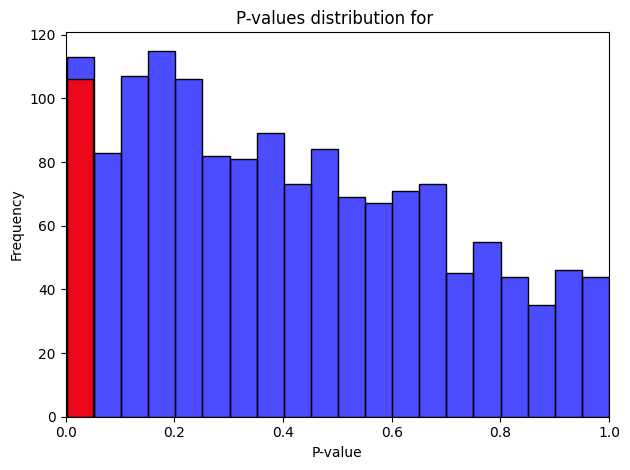

In [10]:
# plotear histograma de p_values para cada ventana temporal en una misma figura, con 3 subplots (1 por ventana temporal)
# color rojo en los p_values menores a 0.05, y azul en los mayores a 0.05
plt.plot(figsize=(15, 5))


with open(f"trama1.pkl", "rb") as f:
    data = pickle.load(f)

p_values = np.array(data["matriz_pvalores"])
p_values = p_values.flatten()
p_values = p_values[~np.isnan(p_values)]

# sns.histplot(p_values, bins=50, ax=axes[idx], )
# sns.histplot(p_values[p_values < 0.05], bins=50, ax=axes[idx], color='red')
sns.histplot(p_values, binwidth=0.05,  color='blue', alpha=0.7, stat='count')
sns.histplot(p_values[p_values <= 0.05], binwidth=0.05,  color='red', alpha=0.9, stat='count')
plt.title(f'P-values distribution for ')
plt.xlabel('P-value')
plt.ylabel('Frequency')
plt.xlim(0, 1)

plt.tight_layout()
plt.show()


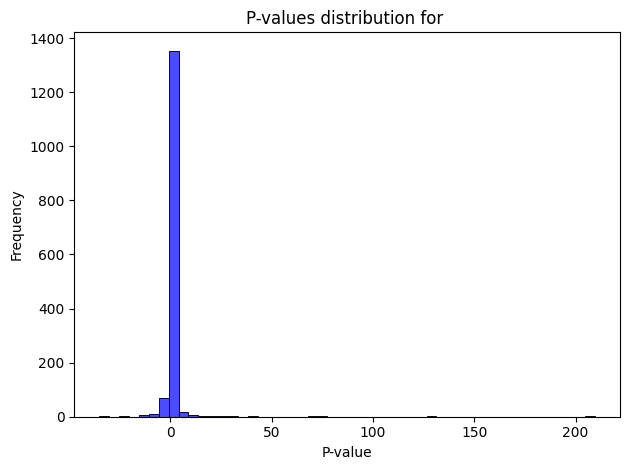

In [14]:
# plotear histograma de p_values para cada ventana temporal en una misma figura, con 3 subplots (1 por ventana temporal)
# color rojo en los p_values menores a 0.05, y azul en los mayores a 0.05
plt.plot(figsize=(15, 5))


with open(f"trama1.pkl", "rb") as f:
    data = pickle.load(f)

p_values = np.array(data["matriz_coeficientes"])
p_values = p_values.flatten()
p_values = p_values[~np.isnan(p_values)]

# sns.histplot(p_values, bins=50, ax=axes[idx], )
# sns.histplot(p_values[p_values < 0.05], bins=50, ax=axes[idx], color='red')
sns.histplot(p_values, bins=50,  color='blue', alpha=0.7, stat='count')
#sns.histplot(p_values[p_values <= 0.05], binwidth=0.05,  color='red', alpha=0.9, stat='count')
plt.title(f'P-values distribution for ')
plt.xlabel('P-value')
plt.ylabel('Frequency')
#plt.xlim(0, 1)

plt.tight_layout()
plt.show()


In [15]:
(p_values>50).sum()

np.int64(4)

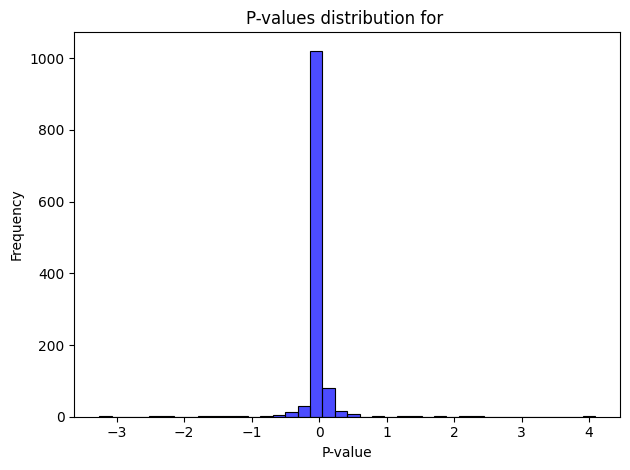

In [19]:
# plotear histograma de p_values para cada ventana temporal en una misma figura, con 3 subplots (1 por ventana temporal)
# color rojo en los p_values menores a 0.05, y azul en los mayores a 0.05
plt.plot(figsize=(15, 5))


with open(f"trama1.pkl", "rb") as f:
    data = pickle.load(f)

data=resultado

p_values = np.array(data["matriz_medias"])
p_values = p_values.flatten()
p_values = p_values[~np.isnan(p_values)]

# sns.histplot(p_values, bins=50, ax=axes[idx], )
# sns.histplot(p_values[p_values < 0.05], bins=50, ax=axes[idx], color='red')
sns.histplot(p_values, bins=40,  color='blue', alpha=0.7, stat='count')
#sns.histplot(p_values[p_values <= 0.05], binwidth=0.05,  color='red', alpha=0.9, stat='count')
plt.title(f'P-values distribution for ')
plt.xlabel('P-value')
plt.ylabel('Frequency')
#plt.xlim(0, 1)

plt.tight_layout()
plt.show()


In [18]:
np.mean(p_values)

np.float64(0.00014411297595011137)

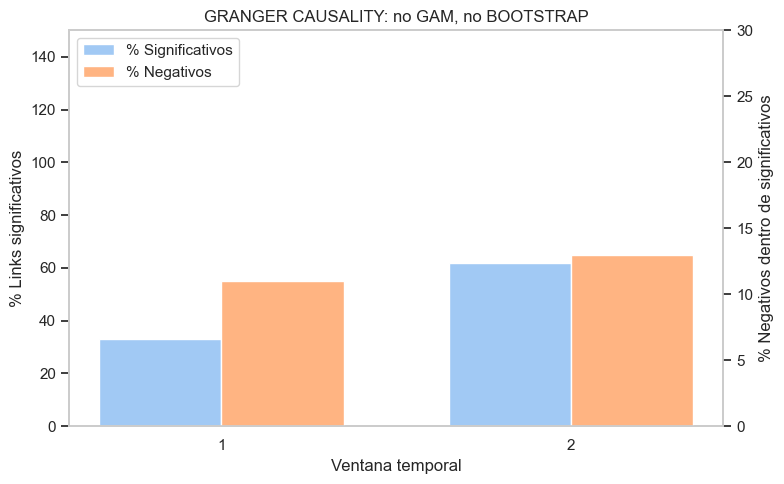

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# Crear DataFrame
# -------------------------
data = {
    "ventana": ["1", "2"],
    "pares_analizados": [5550, 4556],
    "links_significativos": [33, 62],
    "negativos": [11, 13],
}

df = pd.DataFrame(data)

# -------------------------
# Calcular porcentajes
# -------------------------
df["pct_significativos"] = (
    df["links_significativos"] / df["pares_analizados"] * 100
)

df["pct_significativos"] = df["links_significativos"] 


df["pct_negativos_dentro_sig"] = (
    df["negativos"] / df["links_significativos"] * 100
)


df["pct_negativos_dentro_sig"] = df["negativos"] 


# -------------------------
# Estética
# -------------------------
sns.set(style="whitegrid")
palette = sns.color_palette("pastel", 2)

# -------------------------
# Gráfico
# -------------------------
fig, ax1 = plt.subplots(figsize=(8, 5))

x = np.arange(len(df))
width = 0.35

# Barras eje izquierdo
bars1 = ax1.bar(
    x - width/2,
    df["pct_significativos"],
    width,
    color=palette[0]
)

ax1.set_ylabel("% Links significativos")
ax1.set_xlabel("Ventana temporal")
ax1.set_xticks(x)
ax1.set_xticklabels(df["ventana"])

# Barras eje derecho
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    df["pct_negativos_dentro_sig"],
    width,
    color=palette[1]
)

ax2.set_ylabel("% Negativos dentro de significativos")

# -------------------------
# Leyenda limpia (solo una barra de cada tipo)
# -------------------------
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=palette[0], label="% Significativos"),
    Patch(facecolor=palette[1], label="% Negativos")
]

ax1.legend(handles=legend_elements, loc="upper left")

ax1.set_ylim(0,150)
ax2.set_ylim(0,30)
ax1.grid(False)
ax2.grid(False)

plt.title("GRANGER CAUSALITY: no GAM, no BOOTSTRAP")
plt.tight_layout()
plt.show()